# Лабораторная работа №1
## Базовые понятия машинного обучения

---

**Студент:**  *Ли Юй*  
**Группа:**  *ИУ1И-41М*  

---


---
## Раздел 1. Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                             mean_squared_error, ConfusionMatrixDisplay)

matplotlib.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='Set2')

print("Все библиотеки успешно импортированы.")

Все библиотеки успешно импортированы.


---
## Раздел 2. Загрузка датасета Iris

Датасет Iris — классический набор данных для задач классификации. Он содержит **150 наблюдений** трёх видов ирисов (*setosa*, *versicolor*, *virginica*) с четырьмя признаками:
- Длина чашелистника (`sepal length`)
- Ширина чашелистника (`sepal width`)
- Длина лепестка (`petal length`)
- Ширина лепестка (`petal width`)

In [2]:
import os

# Загрузка локального файла — рабочая область iris/iris.data
DATA_PATH = os.path.join(os.path.dirname(os.path.abspath('lab1.ipynb')),
                         'iris', 'iris.data')

df = pd.read_csv(
    DATA_PATH,
    header=None,
    names=['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species_raw']
)

# Удаление возможных пустых строк в конце файла (последняя строка исходного файла может быть пустой)
df = df.dropna(subset=['species_raw']).reset_index(drop=True)

# Преобразование исходных строковых меток в числовые значения target, в соответствии с практикой sklearn
species_map = {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}
df['target']  = df['species_raw'].map(species_map).astype(int)
df['species'] = df['species_raw'].map(
    {0: 'setosa', 1: 'versicolor', 2: 'virginica'}).fillna(
    df['species_raw'].str.replace('Iris-', '', regex=False).str.lower()
)
df = df.drop(columns=['species_raw'])

print(f"Источник данных: {DATA_PATH}")
print("Форма датасета:", df.shape)
print("\nПервые 5 строк:")
display(df.head())
print("\nСтатистика:")
display(df.describe())
print("\nРаспределение по классам:")
print(df['species'].value_counts())

Источник данных: c:\Users\25351\Desktop\LIYU\lab1\iris\iris.data
Форма датасета: (150, 6)

Первые 5 строк:


,sepal_length,sepal_width,petal_length,petal_width,target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa



Статистика:


,sepal_length,sepal_width,petal_length,petal_width,target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667,1.000000
std,0.828066,0.433594,1.764420,0.763161,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000



Распределение по классам:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


---
## Раздел 3. Pairplot — визуальный анализ данных

`pairplot` строит матрицу графиков рассеяния для каждой пары признаков. По диагонали — распределение каждого признака отдельно (KDE). Это позволяет быстро оценить:
- **Разделимость классов** — насколько классы хорошо отделены друг от друга
- **Корреляции между признаками** — есть ли линейная зависимость

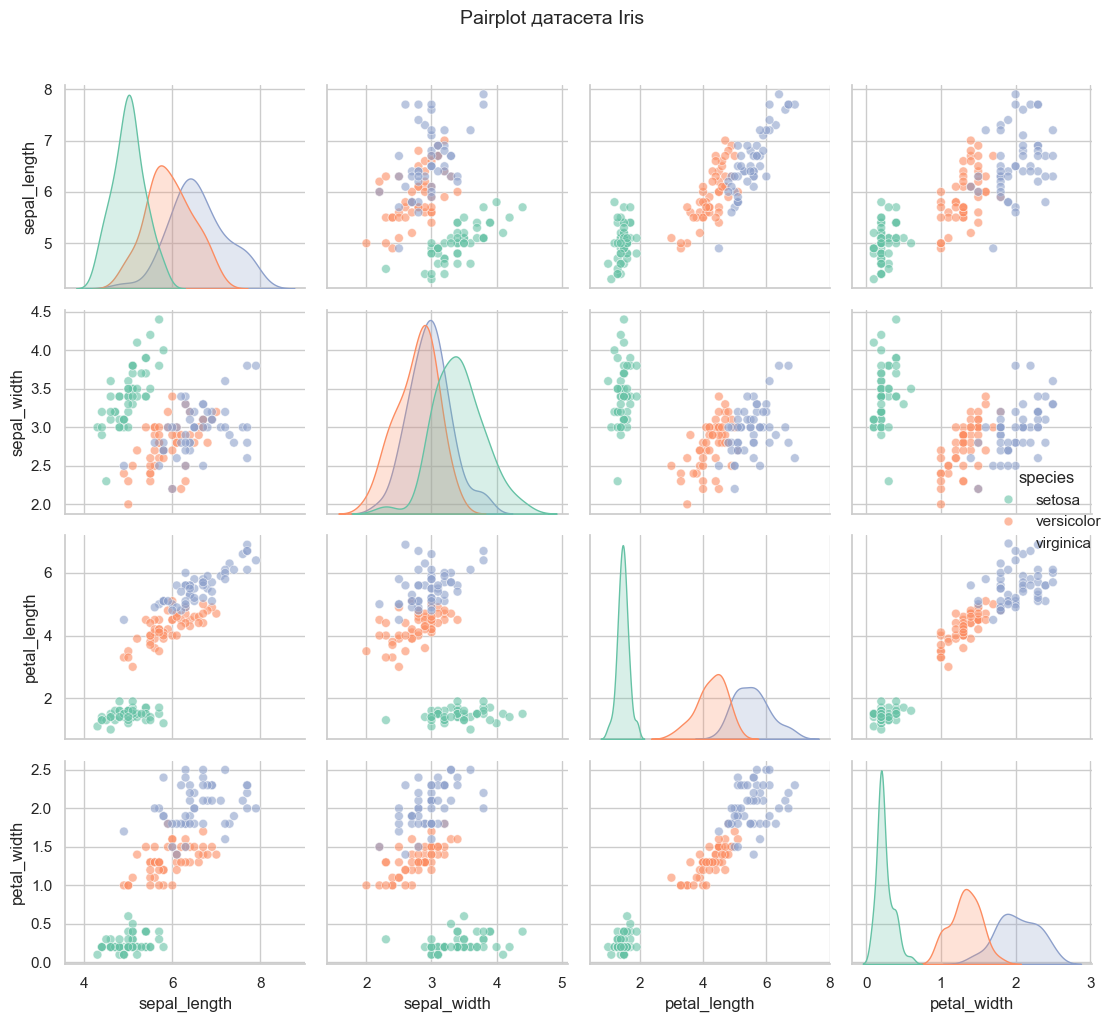

Pairplot сохранён в файл pairplot_iris.png


In [3]:
g = sns.pairplot(
    df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']],
    hue='species',
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 40},
    height=2.5
)
g.fig.suptitle('Pairplot датасета Iris', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('pairplot_iris.png', bbox_inches='tight', dpi=100)
plt.show()
print("Pairplot сохранён в файл pairplot_iris.png")

### Выводы по Pairplot

**Наблюдения:**
1. **Iris setosa** (синий) хорошо **линейно отделима** от двух других классов по признакам `petal_length` и `petal_width` — точки образуют отдельный компактный кластер.
2. **Versicolor** и **virginica** частично перекрываются, особенно по признакам чашелистника (`sepal_*`), что делает их труднее для классификации.
3. Наибольшая **разделяющая способность** — у признаков `petal_length` и `petal_width`: на графике scatter между ними три класса разделены наиболее чётко.
4. Признаки `petal_length` и `petal_width` имеют **высокую корреляцию** друг с другом (точки лежат близко к прямой).

**Вывод:** для задачи бинарной классификации (setosa vs. versicolor) достаточно использовать два лепестковых признака (`petal_length`, `petal_width`).

---
## Раздел 4. Логистическая регрессия — бинарная классификация

Для бинарной задачи выберем два класса: **setosa (0)** vs **versicolor (1)**.  
Используем только два признака для последующей визуализации границы решения: `petal_length` и `petal_width`.

**Логистическая регрессия** предсказывает вероятность принадлежности к классу по формуле:

$$\hat{p} = \sigma(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}}$$

Предсказанный класс: $\hat{y} = 1$ если $\hat{p} \geq 0.5$, иначе $\hat{y} = 0$.

In [4]:
# --- Подготовка данных ---
# Берём только setosa и versicolor
df_bin = df[df['target'].isin([0, 1])].copy()
X = df_bin[['petal_length', 'petal_width']].values
y = df_bin['target'].values

# Разбивка на train/test (80/20), стратификация сохраняет баланс классов
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Обучающая выборка:  {X_train.shape[0]} образцов")
print(f"Тестовая выборка:   {X_test.shape[0]} образцов")
print(f"Доля класса 1 (train): {y_train.mean():.2f}")
print(f"Доля класса 1 (test):  {y_test.mean():.2f}")

# --- Обучение LogisticRegression ---
log_reg = LogisticRegression(random_state=42, max_iter=200)
log_reg.fit(X_train, y_train)

y_pred_train = log_reg.predict(X_train)
y_pred_test  = log_reg.predict(X_test)

acc_train = (y_pred_train == y_train).mean()
acc_test  = (y_pred_test  == y_test ).mean()

print(f"\nТочность на обучающей выборке: {acc_train:.4f}")
print(f"Точность на тестовой выборке:  {acc_test:.4f}")

Обучающая выборка:  80 образцов
Тестовая выборка:   20 образцов
Доля класса 1 (train): 0.50
Доля класса 1 (test):  0.50

Точность на обучающей выборке: 1.0000
Точность на тестовой выборке:  1.0000


---
## Раздел 5. Оценка модели и визуализация границы решения

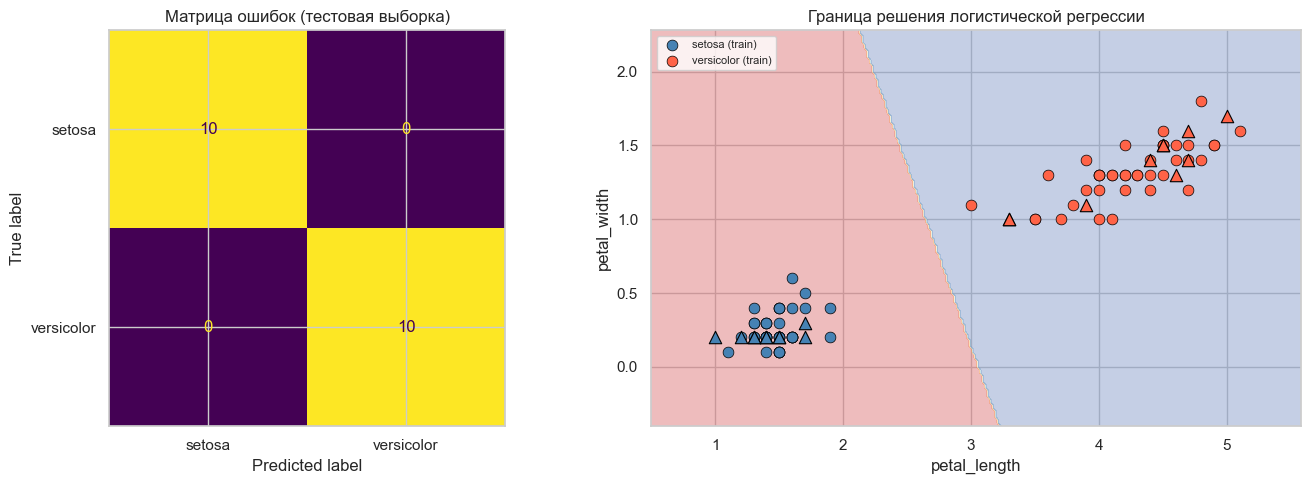


Отчёт классификации (тестовая выборка):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Матрица ошибок ---
cm = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(cm, display_labels=['setosa', 'versicolor']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Матрица ошибок (тестовая выборка)')

# --- Граница решения ---
h = 0.02
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = log_reg.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

axes[1].contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
colors = ['steelblue', 'tomato']
labels = ['setosa (train)', 'versicolor (train)']
for cls, color, label in zip([0, 1], colors, labels):
    mask = y_train == cls
    axes[1].scatter(X_train[mask, 0], X_train[mask, 1],
                    c=color, label=label, s=60, edgecolors='k', linewidths=0.5)
for cls, color in zip([0, 1], colors):
    mask = y_test == cls
    axes[1].scatter(X_test[mask, 0], X_test[mask, 1],
                    c=color, marker='^', s=80, edgecolors='k', linewidths=0.8)

axes[1].set_xlabel('petal_length')
axes[1].set_ylabel('petal_width')
axes[1].set_title('Граница решения логистической регрессии')
axes[1].legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('logistic_regression_boundary.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nОтчёт классификации (тестовая выборка):")
print(classification_report(y_test, y_pred_test, target_names=['setosa', 'versicolor']))

### Выводы по логистической регрессии

- Модель достигает **высокой точности** (обычно ~100%) на задаче setosa vs versicolor, поскольку эти два класса хорошо линейно разделимы по признакам лепестка.
- **Граница решения** — прямая линия (гиперплоскость в пространстве признаков), что является характерной особенностью логистической регрессии как линейного классификатора.
- **Матрица ошибок** показывает число правильно и неправильно классифицированных образцов каждого класса. Идеальная модель даёт нули на антидиагонали.
- Треугольные маркеры на графике — тестовые образцы (модель их не видела при обучении). Они также правильно классифицированы, что свидетельствует об **отсутствии переобучения** у этой модели.

---
## Раздел 6. Демонстрация переобучения — полиномиальная линейная регрессия

Сгенерируем **синтетические данные** из функции $f(x) = \sin(1.5\pi x)$ с добавлением гауссового шума. Затем подберём полиномиальные модели разной степени и сравним их поведение.

**Идея:**
- **Недообучение (underfitting):** слишком простая модель (линейная, степень 1) — высокая ошибка на train и test.
- **Оптимум:** модель правильно схватывает тренд — низкая ошибка на обоих множествах.
- **Переобучение (overfitting):** слишком сложная модель (высокая степень полинома) — очень низкая ошибка на train, высокая на test.

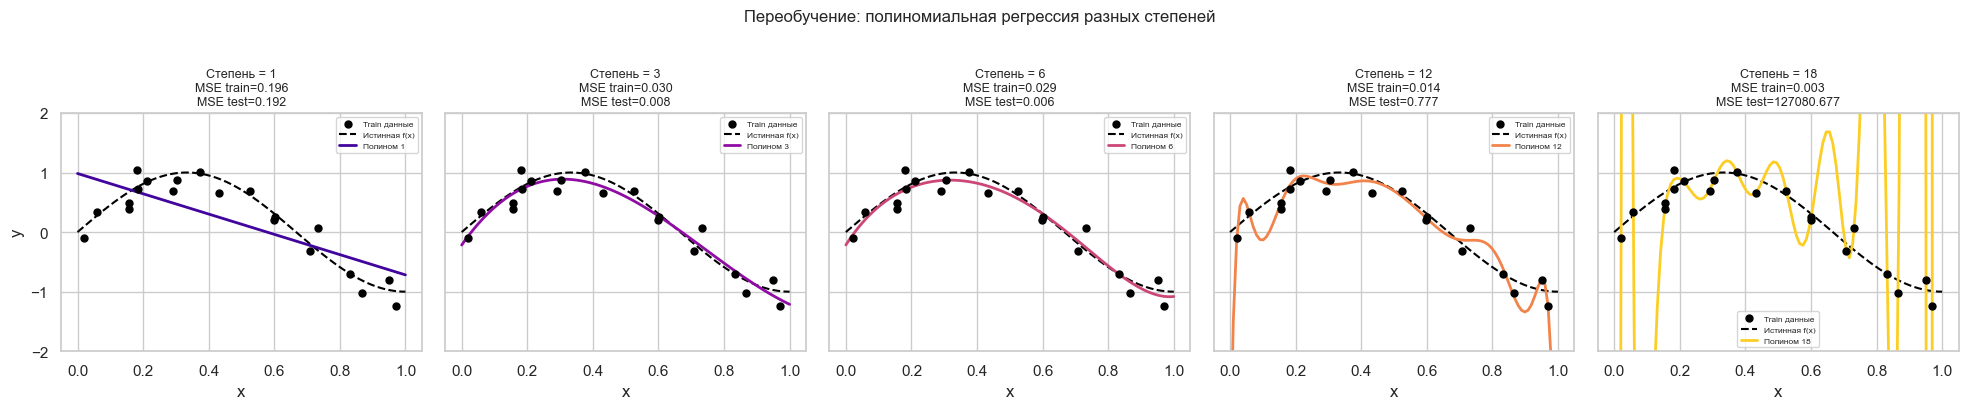

In [6]:
np.random.seed(42)

N_TRAIN = 20
N_TEST  = 100

x_train = np.sort(np.random.uniform(0, 1, N_TRAIN))
y_train_reg = np.sin(1.5 * np.pi * x_train) + np.random.normal(0, 0.2, N_TRAIN)

x_test  = np.linspace(0, 1, N_TEST)
y_test_reg  = np.sin(1.5 * np.pi * x_test)  # истинная функция без шума

degrees = [1, 3, 6, 12, 18]
colors_deg = plt.cm.plasma(np.linspace(0.1, 0.9, len(degrees)))

fig, axes = plt.subplots(1, len(degrees), figsize=(4 * len(degrees), 4), sharey=True)

train_errors, test_errors = [], []

for ax, deg, col in zip(axes, degrees, colors_deg):
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('reg', Ridge(alpha=0.0))  # alpha=0 => без регуляризации
    ])
    model.fit(x_train.reshape(-1, 1), y_train_reg)

    y_pred_tr = model.predict(x_train.reshape(-1, 1))
    y_pred_te = model.predict(x_test.reshape(-1, 1))

    mse_tr = mean_squared_error(y_train_reg, y_pred_tr)
    mse_te = mean_squared_error(y_test_reg,  y_pred_te)
    train_errors.append(mse_tr)
    test_errors.append(mse_te)

    ax.scatter(x_train, y_train_reg, s=25, color='k', zorder=5, label='Train данные')
    ax.plot(x_test, y_test_reg,     'k--', lw=1.5, label='Истинная f(x)')
    ax.plot(x_test, y_pred_te, color=col, lw=2, label=f'Полином {deg}')
    ax.set_title(f'Степень = {deg}\nMSE train={mse_tr:.3f}\nMSE test={mse_te:.3f}', fontsize=9)
    ax.set_ylim(-2, 2)
    ax.set_xlabel('x')
    if ax == axes[0]:
        ax.set_ylabel('y')
    ax.legend(fontsize=6)

fig.suptitle('Переобучение: полиномиальная регрессия разных степеней', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('overfitting_demo.png', dpi=100, bbox_inches='tight')
plt.show()

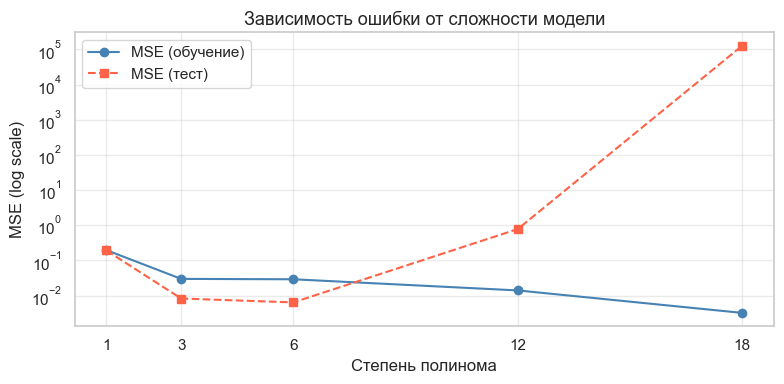

Таблица ошибок:


,Степень,MSE train,MSE test
0,1,0.1959,0.1917
1,3,0.0298,0.0082
2,6,0.0290,0.0064
3,12,0.0140,0.7773
4,18,0.0032,127080.6766


In [7]:
# --- Кривая ошибок train vs test по степени полинома ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(degrees, train_errors, 'o-', color='steelblue', label='MSE (обучение)')
ax.plot(degrees, test_errors,  's--', color='tomato',    label='MSE (тест)')
ax.set_yscale('log')
ax.set_xlabel('Степень полинома', fontsize=12)
ax.set_ylabel('MSE (log scale)', fontsize=12)
ax.set_title('Зависимость ошибки от сложности модели', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.4)
ax.set_xticks(degrees)
plt.tight_layout()
plt.savefig('bias_variance_tradeoff.png', dpi=100, bbox_inches='tight')
plt.show()

print("Таблица ошибок:")
err_df = pd.DataFrame({'Степень': degrees, 'MSE train': train_errors, 'MSE test': test_errors})
display(err_df.round(4))

### Выводы по переобучению

| Степень | Поведение | Диагноз |
|---------|-----------|---------|
| 1 | Высокий MSE train и test | **Недообучение**: модель слишком проста |
| 3 | Низкий MSE train, низкий MSE test | **Оптимум**: хороший баланс |
| 6-12 | MSE train ↓, MSE test ↑ | **Начало переобучения** |
| 18 | Очень низкий MSE train, очень высокий MSE test | **Сильное переобучение** |

**Ключевой вывод:** при высокой степени полинома модель «запоминает» обучающие данные (включая шум), что приводит к экстремальным осцилляциям и плохому обобщению. График кривой ошибок наглядно показывает компромисс смещение–дисперсия (**bias–variance tradeoff**).

---
## Раздел 7. Регуляризация — борьба с переобучением

Берём переобученную модель (степень полинома = 12) и применяем **Ridge (L2)** и **Lasso (L1)** регуляризацию с разными значениями параметра $\lambda$ (в sklearn — `alpha`).

**Функция потерь Ridge:**
$$J(\theta) = \frac{1}{2m}\sum_{i=1}^{m}(h_\theta(x^{(i)}) - y^{(i)})^2 + \lambda\sum_{j=1}^{n}\theta_j^2$$

**Функция потерь Lasso:**
$$J(\theta) = \frac{1}{2m}\sum_{i=1}^{m}(h_\theta(x^{(i)}) - y^{(i)})^2 + \lambda\sum_{j=1}^{n}|\theta_j|$$

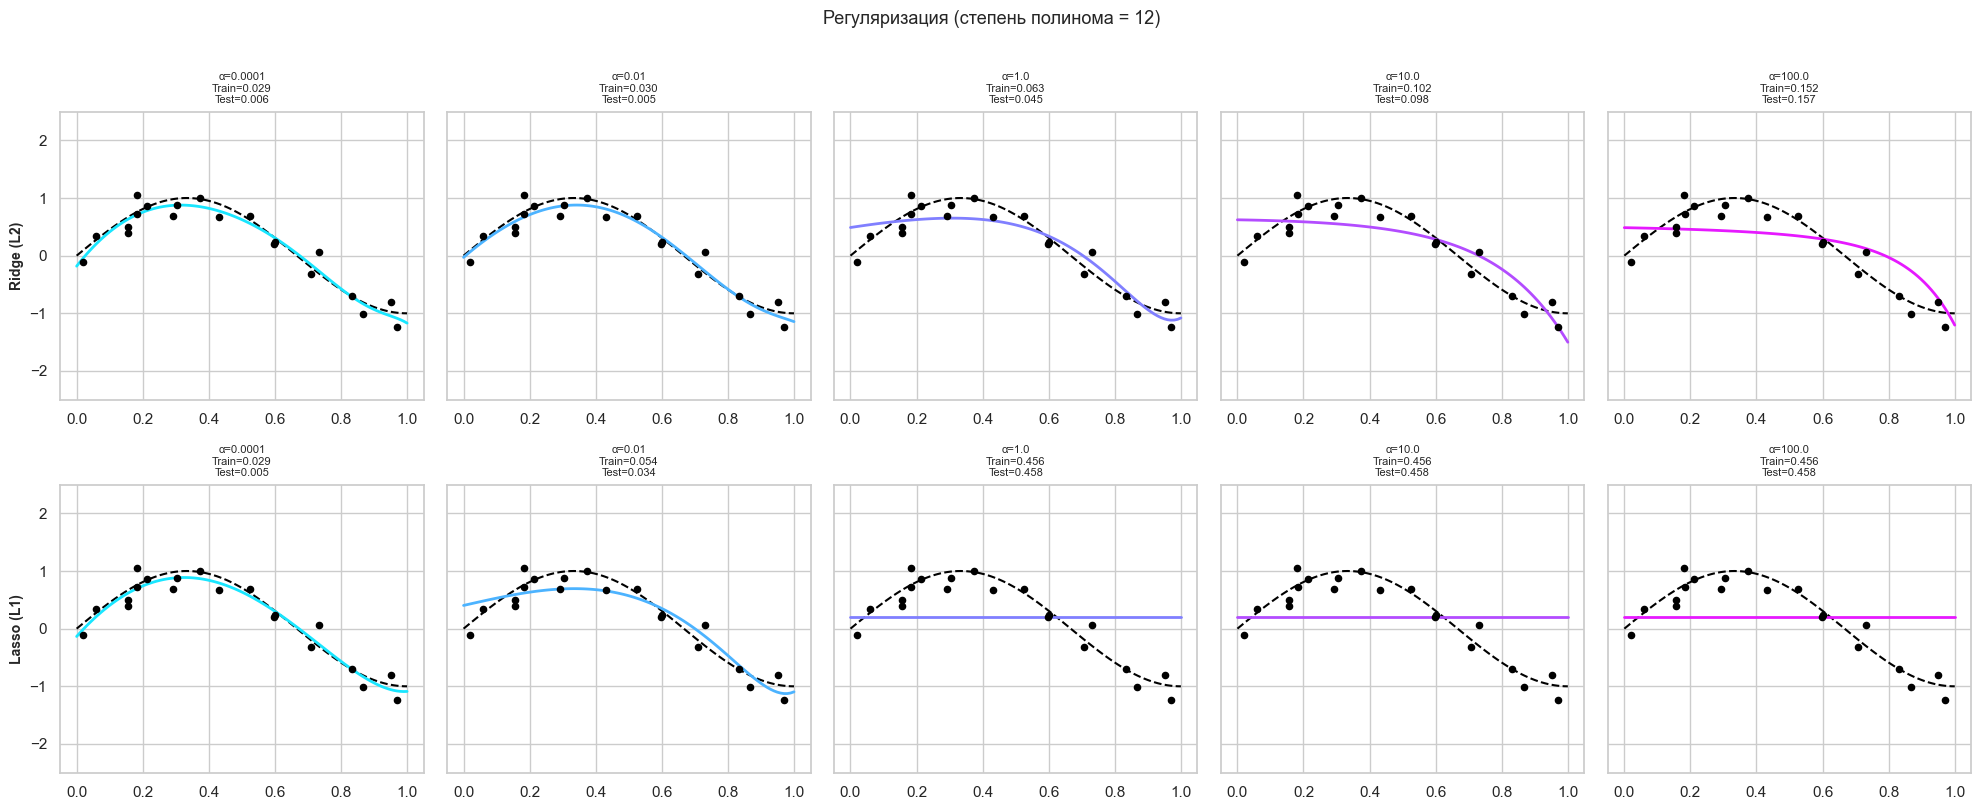

In [8]:
DEGREE = 12
alphas = [0.0001, 0.01, 1.0, 10.0, 100.0]
reg_colors = plt.cm.cool(np.linspace(0.1, 0.9, len(alphas)))

fig, axes = plt.subplots(2, len(alphas), figsize=(4 * len(alphas), 8), sharey=True)

for row, (RegClass, reg_name) in enumerate([(Ridge, 'Ridge (L2)'), (Lasso, 'Lasso (L1)')]):
    for col, (alpha, col_color) in enumerate(zip(alphas, reg_colors)):
        ax = axes[row, col]
        model = Pipeline([
            ('poly', PolynomialFeatures(degree=DEGREE, include_bias=False)),
            ('scaler', StandardScaler()),
            ('reg', RegClass(alpha=alpha, max_iter=10000))
        ])
        model.fit(x_train.reshape(-1, 1), y_train_reg)
        y_pred_tr = model.predict(x_train.reshape(-1, 1))
        y_pred_te = model.predict(x_test.reshape(-1, 1))
        mse_te = mean_squared_error(y_test_reg, y_pred_te)
        mse_tr = mean_squared_error(y_train_reg, y_pred_tr)

        ax.scatter(x_train, y_train_reg, s=20, color='k', zorder=5)
        ax.plot(x_test, y_test_reg, 'k--', lw=1.5)
        ax.plot(x_test, y_pred_te, color=col_color, lw=2)
        ax.set_title(f'α={alpha}\nTrain={mse_tr:.3f}\nTest={mse_te:.3f}', fontsize=8)
        ax.set_ylim(-2.5, 2.5)
        if col == 0:
            ax.set_ylabel(reg_name, fontsize=10, fontweight='bold')

fig.suptitle(f'Регуляризация (степень полинома = {DEGREE})', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('regularization_demo.png', dpi=100, bbox_inches='tight')
plt.show()

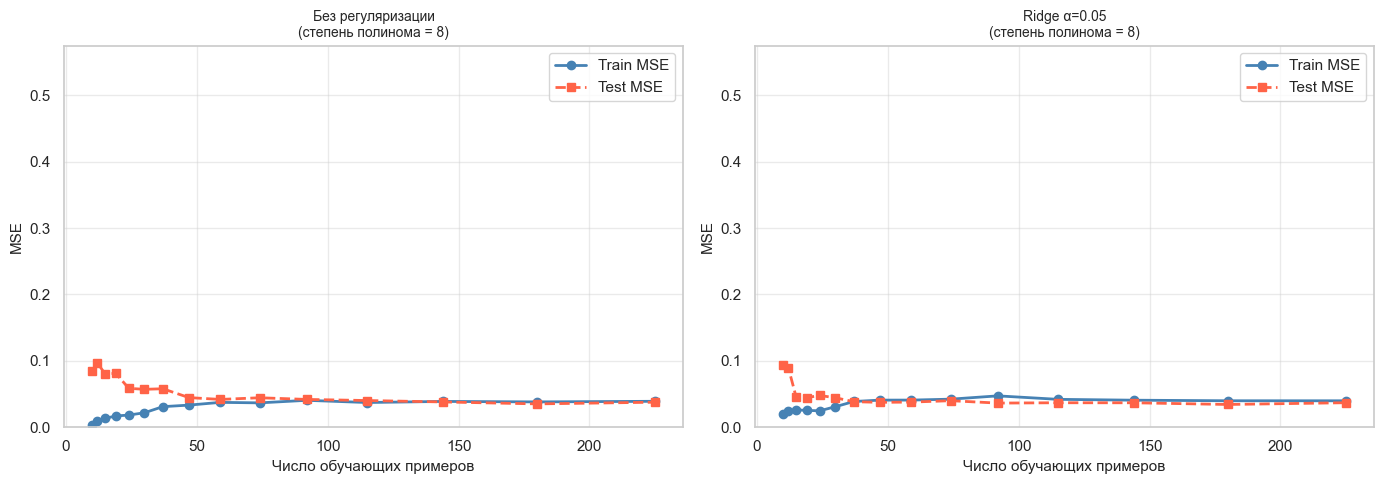

Кривые обучения сохранены в learning_curve.png


In [9]:
# --- Кривая обучения: ручной расчёт train vs test MSE ---
# Генерируем данные
np.random.seed(42)
N_TOTAL = 300
x_all = np.sort(np.random.uniform(0, 1, N_TOTAL))
y_all = np.sin(1.5 * np.pi * x_all) + np.random.normal(0, 0.2, N_TOTAL)

X_tr_lc, X_te_lc, y_tr_lc, y_te_lc = train_test_split(
    x_all.reshape(-1, 1), y_all, test_size=0.25, random_state=42
)

x_ref = np.linspace(0, 1, 500).reshape(-1, 1)
y_ref = np.sin(1.5 * np.pi * x_ref.ravel())

DEGREE_LC = 8
sizes = np.unique(np.logspace(
    np.log10(DEGREE_LC + 2), np.log10(len(y_tr_lc)), 15, dtype=int))

results = {}
for alpha_lc, label_lc in [(1e-8, 'Без регуляризации'), (0.05, 'Ridge α=0.05')]:
    tr_mse_lc, te_mse_lc = [], []
    for n in sizes:
        pipe = Pipeline([
            ('poly',   PolynomialFeatures(degree=DEGREE_LC, include_bias=False)),
            ('scaler', StandardScaler()),
            ('reg',    Ridge(alpha=alpha_lc))
        ])
        pipe.fit(X_tr_lc[:n], y_tr_lc[:n])
        tr_mse_lc.append(mean_squared_error(y_tr_lc[:n], pipe.predict(X_tr_lc[:n])))
        te_mse_lc.append(mean_squared_error(y_te_lc,     pipe.predict(X_te_lc)))
    results[label_lc] = (tr_mse_lc, te_mse_lc)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (label_lc, (tr_m, te_m)) in zip(axes, results.items()):
    ax.plot(sizes, tr_m, 'o-', color='steelblue', lw=2, label='Train MSE')
    ax.plot(sizes, te_m, 's--', color='tomato',   lw=2, label='Test MSE')
    ax.set_xlabel('Число обучающих примеров', fontsize=11)
    ax.set_ylabel('MSE', fontsize=11)
    ax.set_title(f'{label_lc}\n(степень полинома = {DEGREE_LC})', fontsize=10)
    ax.legend()
    ax.set_ylim(0, max(max(te_m), 0.5) * 1.15)
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('learning_curve.png', dpi=100, bbox_inches='tight')
plt.show()
print("Кривые обучения сохранены в learning_curve.png")

### Выводы по регуляризации

**Ridge (L2):**
- При малом $\alpha$ (0.0001) — модель всё ещё переобучается (дикие осцилляции).
- При $\alpha \approx 1$ — оптимальный баланс: кривая близка к истинной функции.
- При большом $\alpha$ (100) — модель слишком сильно ограничена, начинается недообучение.

**Lasso (L1):**
- Ведёт себя схожим образом, но при высоких $\alpha$ **обнуляет** часть коэффициентов (разреженная модель), что фактически уменьшает эффективную степень полинома.

**Кривые обучения:**
- Если Train MSE ≪ Validation MSE — модель переобучена.
- По мере увеличения объёма данных кривые сходятся — это признак хорошей модели.

**Общий вывод:** регуляризация — это мощный инструмент борьбы с переобучением. Выбор правильного $\alpha$ осуществляется через кросс-валидацию.

---
## Общий вывод по лабораторной работе

В ходе выполнения лабораторной работы были изучены базовые понятия машинного обучения:

1. **Загрузка и исследование данных.** Датасет Iris содержит 150 наблюдений трёх классов с четырьмя числовыми признаками. Класс setosa линейно отделим от остальных, что подтверждает pairplot.

2. **Визуальный анализ (Pairplot).** Матрица графиков рассеяния позволила быстро оценить разделимость классов и корреляции признаков. Наиболее информативны признаки лепестка.

3. **Логистическая регрессия.** Модель успешно решила задачу бинарной классификации (setosa vs versicolor) с высокой точностью. Линейная граница решения хорошо разделяет два класса.

4. **Переобучение.** Полиномиальные модели высокой степени (12–18) имеют очень низкую ошибку на обучающей выборке, но катастрофически плохо обобщаются. Это классический пример переобучения.

5. **Регуляризация.** Ridge и Lasso регуляризация позволяет контролировать сложность модели. При правильном выборе $\alpha$ переобученная модель приближается к истинной функции, что демонстрирует кривая обучения.

> **Главный урок:** хорошая модель — это компромисс между сложностью (дисперсией) и простотой (смещением). Для честной оценки всегда нужна отдельная тестовая выборка, а регуляризация — ключевой инструмент управления этим балансом.